## Comparing sophronia data processed with LSC settings vs no thresholds

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob
from pathlib import Path
import os
import re
import sys
from tqdm import tqdm

sys.path.append("/gluster/data/next/software/IC_311024/")
sys.path.append(os.path.expanduser('~/code/eol_hsrl_python'))
#sys.path.append("/home/e78368jw/Documents/NEXT_CODE/next_misc/")
os.environ['ICTDIR']='/gluster/data/next/software/IC_311024/'

from invisible_cities.io.dst_io        import df_writer
from invisible_cities.io.dst_io        import load_dst

from invisible_cities.cities.beersheba import cut_over_Q
from invisible_cities.cities.beersheba import drop_isolated 


In [18]:
def raw_plotter(q, evt, pitch = 15.55):
    '''
    just plots the hits, nothing smart
    '''

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    xx = np.arange(q.X.min(), q.X.max() + pitch, pitch)
    yy = np.arange(q.Y.min(), q.Y.max() + pitch, pitch)
    zz = np.sort(q.Z.unique())

    axes[0].hist2d(q.X, q.Y, bins=[xx, yy], weights=q.Q, cmin=0.0001);
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(q.X, q.Z, bins=[xx, zz], weights=q.Q, cmin=0.0001);
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');


    axes[2].hist2d(q.Y, q.Z, bins=[yy, zz], weights=q.Q, cmin=0.0001);
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');
    fig.suptitle("rebinned in Z")
    plt.show(fig)



In [3]:
low_thr_files = glob('low_thr/*000[0-9]*')
low_thr_files  = sorted(low_thr_files, key=lambda f: int(re.search(r'_000(\d)_', f).group(1)))

lsc_run_files = glob('lsc_run/*000[0-9]*')
lsc_run_files = sorted(lsc_run_files, key=lambda f: int(re.search(r'_000(\d)_', f).group(1)))

print(low_thr_files)
print(lsc_run_files)


['low_thr/run_15281_0000_ldc1.h5', 'low_thr/run_15281_0001_ldc1.h5', 'low_thr/run_15281_0002_ldc1.h5', 'low_thr/run_15281_0003_ldc1.h5', 'low_thr/run_15281_0004_ldc1.h5', 'low_thr/run_15281_0005_ldc1.h5', 'low_thr/run_15281_0006_ldc1.h5', 'low_thr/run_15281_0007_ldc1.h5', 'low_thr/run_15281_0008_ldc1.h5', 'low_thr/run_15281_0009_ldc1.h5']
['lsc_run/run_15281_0000_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0001_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0002_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0003_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0004_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0005_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0006_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0007_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0008_ldc1_trg2.v2.3.1.20250429.HEDesman.sophron

# find event with energy in ROI

evt 9: 2.388865595046239.MeV


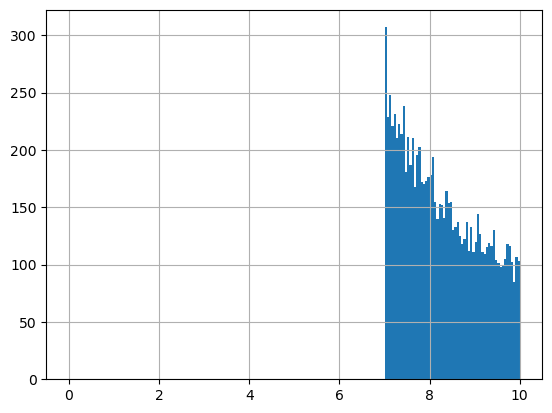

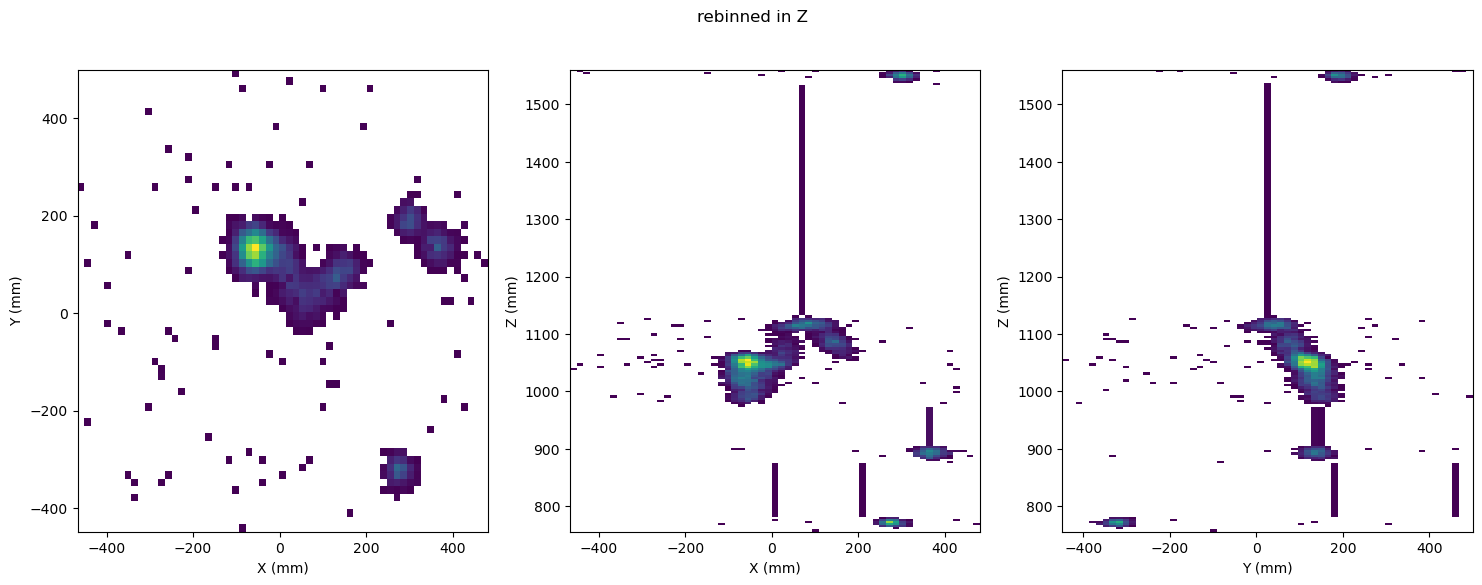

In [4]:
evt_energies = []
for lsc_file, thr_file in zip(lsc_run_files, low_thr_files):

    df = load_dst(lsc_file, 'RECO', 'Events')
    df.Q.hist(bins = 200, range = [0,10])
    for evt, df_evt in df.groupby('event'):
        print(f'evt {evt}: {df_evt.Ec.sum()}.MeV')
        evt_energies.append(df_evt.Ec.sum())
        raw_plotter(df_evt, evt)
        break
    break

Did it more or less by eye, list of events to follow.
Plan is to have each event plotted with cut_over_Q of 5 PES to show the comparison.

** we have to use 7 PES because they did in this processing ...

In [4]:
from tqdm import tqdm

In [52]:
# define cut_over_Q and drop_isolated object
q_thr     = 8
drop_dist = [15.55, 15.55]

cut_sensors   = cut_over_Q(q_thr, ['E', 'Ec'])
drop_sensors  = drop_isolated(drop_dist, ['E', 'Ec'])

# list of evts
evts = [177, 219, 737, 842, 849, 954, 1045, 1087, 1094]

# generate folders to store data
for evt in evts:
    Path(f'evt{evt}_images').mkdir(parents=True, exist_ok=True)

lsc_EOI = []
thr_EOI = []
for lsc_file, thr_file in tqdm(zip(lsc_run_files, low_thr_files)):

    df_lsc = load_dst(lsc_file, 'RECO', 'Events')
    df_thr = load_dst(thr_file, 'RECO', 'Events')
    # extract the events of interest from the df
    df_lsc = df_lsc[df_lsc.event.isin(evts)]
    df_thr = df_thr[df_thr.event.isin(evts)]
    # cut and drop
    df_lsc  = cut_sensors(df_lsc)
    df_thr  = cut_sensors(df_thr)
    
    df_lsc  = drop_sensors(df_lsc)
    df_thr  = drop_sensors(df_thr)

    lsc_EOI.append(df_lsc)
    thr_EOI.append(df_thr)



10it [04:38, 27.82s/it]


In [53]:
lsc_EOI_working = lsc_EOI[:2]
thr_EOI_working = thr_EOI[:2]

In [54]:
display(lsc_EOI_working[0])

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,177,1.746555e+09,0,114.823133,10.641630,1,366.625,-109.225,0.0,0.0,835.662875,13.651507,308.388829,-1.0,0.001713,-1,-1.0
1,177,1.746555e+09,0,114.823133,10.641630,1,351.075,-124.775,0.0,0.0,839.529125,16.819176,503.123916,-1.0,0.002759,-1,-1.0
2,177,1.746555e+09,0,114.823133,10.641630,1,351.075,-109.225,0.0,0.0,839.529125,16.880341,504.953584,-1.0,0.002753,-1,-1.0
3,177,1.746555e+09,0,114.823133,10.641630,1,351.075,-93.675,0.0,0.0,839.529125,9.616236,287.657271,-1.0,0.001577,-1,-1.0
4,177,1.746555e+09,0,114.823133,10.641630,1,366.625,-140.325,0.0,0.0,839.529125,8.812063,263.601488,-1.0,0.001481,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5411,737,1.746555e+09,5,272.704379,196.671247,1,396.725,276.525,0.0,0.0,1202.971125,8.266233,44.254136,-1.0,0.000397,-1,-1.0
5412,737,1.746555e+09,5,272.704379,196.671247,1,351.075,260.975,0.0,0.0,1206.091750,10.486255,43.809080,-1.0,0.000287,-1,-1.0
5413,737,1.746555e+09,5,272.704379,196.671247,1,366.625,245.425,0.0,0.0,1206.091750,16.206469,67.706774,-1.0,0.000437,-1,-1.0
5414,737,1.746555e+09,5,272.704379,196.671247,1,366.625,260.975,0.0,0.0,1206.091750,12.279106,51.299187,-1.0,0.000354,-1,-1.0


In [55]:
# plot and compare each event
for lsc_evt, thr_evt in zip(lsc_EOI_working, thr_EOI_working):
    
    
    pitch = 15.55
    try:
        for ((lsc, df_lsc), (thr, df_thr)) in zip(lsc_evt.groupby('event'), thr_evt.groupby('event')):
            fig, axes = plt.subplots(1, 2, figsize=(13, 6))

            xx_thr = np.arange(df_thr.X.min(), df_thr.X.max() + pitch, pitch)
            yy_thr = np.arange(df_thr.Y.min(), df_thr.Y.max() + pitch, pitch)
            zz_thr = np.sort(df_thr.Z.unique())

            xx_lsc = np.arange(df_lsc.X.min(), df_lsc.X.max() + pitch, pitch)
            yy_lsc = np.arange(df_lsc.Y.min(), df_lsc.Y.max() + pitch, pitch)
            zz_lsc = np.sort(df_lsc.Z.unique())


            # exclude negative energy hits
            df_lsc = df_lsc[df_lsc.E > 0]
            df_thr = df_thr[df_thr.E > 0]
            
            axes[0].hist2d(df_lsc.X, df_lsc.Y, bins=[xx_lsc, yy_lsc], weights=df_lsc.Q, cmin=0.0001, cmax = 4200);
            axes[0].set_xlabel('X (mm)');
            axes[0].set_ylabel('Y (mm)');

            axes[1].hist2d(df_thr.X, df_thr.Y, bins=[xx_lsc, yy_lsc], weights=df_thr.Q, cmin=0.0001, cmax = 4200);
            axes[1].set_xlabel('X (mm)');
            axes[1].set_ylabel('Y (mm)');
            event = df_thr.event.unique()[0]
            plt.suptitle(f'evt{event} - LSC vs RAW')
            plt.savefig(f'comparisons/{event}')
            plt.close()
            print('thr')
            display(df_thr)
            print('lsc')
            display(df_lsc)
            print('='*20)
    except Exception as e:
        print(f'broke: {e}')

thr


,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
2,177,1.746555e+09,22,51.369641,10.489568,1,288.875,-32.475,0.0,0.0,803.326375,10.684254,0.113379,-1.0,-186.741483,-1,-1.0
3,177,1.746555e+09,22,51.369641,10.489568,1,-373.775,-48.025,0.0,0.0,810.789750,10.187858,0.133359,-1.0,-186.741483,-1,-1.0
4,177,1.746555e+09,22,51.369641,10.489568,1,366.625,-109.225,0.0,0.0,835.614000,13.950859,18.634732,-1.0,-186.741483,-1,-1.0
5,177,1.746555e+09,22,51.369641,10.489568,1,351.075,-124.775,0.0,0.0,839.518000,17.139090,70.690247,-1.0,-186.741483,-1,-1.0
6,177,1.746555e+09,22,51.369641,10.489568,1,351.075,-109.225,0.0,0.0,839.518000,17.294159,71.329831,-1.0,-186.741483,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2074,177,1.746555e+09,26,2.257494,8.962107,1,-297.025,-185.975,0.0,0.0,1899.817500,15.435706,59.542690,-1.0,-6016.000000,-1,-1.0
2075,177,1.746555e+09,26,2.257494,8.962107,1,-281.475,-201.525,0.0,0.0,1899.817500,10.013412,38.626381,-1.0,-6016.000000,-1,-1.0
2076,177,1.746555e+09,26,2.257494,8.962107,1,-265.925,-201.525,0.0,0.0,1899.817500,10.454169,40.326588,-1.0,-6016.000000,-1,-1.0
2077,177,1.746555e+09,26,2.257494,8.962107,1,-250.375,-185.975,0.0,0.0,1899.817500,9.093193,35.076671,-1.0,-6016.000000,-1,-1.0


lsc


,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,177,1.746555e+09,0,114.823133,10.641630,1,366.625,-109.225,0.0,0.0,835.662875,13.651507,308.388829,-1.0,0.001713,-1,-1.0
1,177,1.746555e+09,0,114.823133,10.641630,1,351.075,-124.775,0.0,0.0,839.529125,16.819176,503.123916,-1.0,0.002759,-1,-1.0
2,177,1.746555e+09,0,114.823133,10.641630,1,351.075,-109.225,0.0,0.0,839.529125,16.880341,504.953584,-1.0,0.002753,-1,-1.0
3,177,1.746555e+09,0,114.823133,10.641630,1,351.075,-93.675,0.0,0.0,839.529125,9.616236,287.657271,-1.0,0.001577,-1,-1.0
4,177,1.746555e+09,0,114.823133,10.641630,1,366.625,-140.325,0.0,0.0,839.529125,8.812063,263.601488,-1.0,0.001481,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1937,177,1.746555e+09,1,-154.219031,-96.610473,1,-312.575,-171.425,0.0,0.0,1897.704000,8.463993,80.423467,-1.0,0.000446,-1,-1.0
1938,177,1.746555e+09,1,-154.219031,-96.610473,1,-297.025,-171.425,0.0,0.0,1897.704000,19.919748,189.274166,-1.0,0.001046,-1,-1.0
1939,177,1.746555e+09,1,-154.219031,-96.610473,1,-281.475,-171.425,0.0,0.0,1897.704000,27.342316,259.802178,-1.0,0.001429,-1,-1.0
1940,177,1.746555e+09,1,-154.219031,-96.610473,1,-265.925,-201.525,0.0,0.0,1901.669750,11.378285,263.523970,-1.0,0.001462,-1,-1.0


thr


...

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
5439,1087,1.746555e+09,0,30.731085,110.275638,1,149.925,291.575,0.0,0.0,945.028750,9.033890,310.558650,-1.0,0.001720,-1,-1.0
5440,1087,1.746555e+09,0,30.731085,110.275638,1,119.825,291.575,0.0,0.0,948.718875,9.823363,181.317925,-1.0,0.001000,-1,-1.0
5441,1087,1.746555e+09,0,30.731085,110.275638,1,119.825,307.125,0.0,0.0,948.718875,10.357726,191.181100,-1.0,0.001056,-1,-1.0
5442,1087,1.746555e+09,0,30.731085,110.275638,1,134.375,307.125,0.0,0.0,948.718875,9.522449,175.763710,-1.0,0.000978,-1,-1.0
5443,1087,1.746555e+09,0,30.731085,110.275638,1,149.925,276.025,0.0,0.0,948.718875,9.475585,174.898694,-1.0,0.000975,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7370,1087,1.746555e+09,0,30.731085,110.275638,1,10.975,199.275,0.0,0.0,1207.844000,8.413967,41.156399,-1.0,0.000220,-1,-1.0
7371,1087,1.746555e+09,0,30.731085,110.275638,1,26.525,214.825,0.0,0.0,1207.844000,17.002308,83.165735,-1.0,0.000449,-1,-1.0
7372,1087,1.746555e+09,0,30.731085,110.275638,1,26.525,230.375,0.0,0.0,1207.844000,10.085157,49.330922,-1.0,0.000269,-1,-1.0
7373,1087,1.746555e+09,0,30.731085,110.275638,1,42.075,214.825,0.0,0.0,1207.844000,15.207769,74.387861,-1.0,0.000401,-1,-1.0


thr


,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
8104,1094,1.746555e+09,5,7.846451,11.465869,1,381.175,-232.625,0.0,0.0,-170.677312,8.116385,0.029485,-1.0,-492.608430,-1,-1.0
8105,1094,1.746555e+09,5,7.846451,11.465869,1,-312.575,-279.275,0.0,0.0,-122.214875,8.575130,0.004781,-1.0,-492.608430,-1,-1.0
8106,1094,1.746555e+09,5,7.846451,11.465869,1,57.625,-202.025,0.0,0.0,-50.904500,9.270940,0.129867,-1.0,-492.608430,-1,-1.0
8107,1094,1.746555e+09,5,7.846451,11.465869,1,165.475,137.075,0.0,0.0,-45.965563,8.755433,0.151269,-1.0,-492.608430,-1,-1.0
8108,1094,1.746555e+09,5,7.846451,11.465869,1,-3.575,-16.425,0.0,0.0,21.449500,8.594370,0.254382,-1.0,-492.608430,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9835,1094,1.746555e+09,6,3.282007,1.463250,1,-65.775,-325.425,0.0,0.0,846.159125,9.540289,62.568493,-1.0,-2448.475248,-1,-1.0
9836,1094,1.746555e+09,6,3.282007,1.463250,1,-112.425,-294.325,0.0,0.0,850.101000,10.381536,26.742291,-1.0,-2448.475248,-1,-1.0
9837,1094,1.746555e+09,6,3.282007,1.463250,1,-81.325,-309.875,0.0,0.0,850.101000,11.533811,29.710489,-1.0,-2448.475248,-1,-1.0
9838,1094,1.746555e+09,6,3.282007,1.463250,1,-81.325,-294.325,0.0,0.0,850.101000,9.083101,23.397591,-1.0,-2448.475248,-1,-1.0


lsc


,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
7375,1094,1.746555e+09,0,14.861882,12.841345,1,104.275,13.675,0.0,0.0,356.510000,9.626658,164.912305,-1.0,0.000852,-1,-1.0
7376,1094,1.746555e+09,0,14.861882,12.841345,1,165.475,-217.575,0.0,0.0,356.510000,8.171220,139.979486,-1.0,0.000711,-1,-1.0
7377,1094,1.746555e+09,0,14.861882,12.841345,1,119.825,-0.875,0.0,0.0,359.963500,12.626978,221.614446,-1.0,0.001144,-1,-1.0
7378,1094,1.746555e+09,0,14.861882,12.841345,1,104.275,13.675,0.0,0.0,359.963500,12.897253,226.358009,-1.0,0.001169,-1,-1.0
7379,1094,1.746555e+09,0,14.861882,12.841345,1,104.275,29.225,0.0,0.0,359.963500,16.680664,292.760163,-1.0,0.001507,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8976,1094,1.746555e+09,1,-61.463783,-195.273854,1,-96.875,-294.325,0.0,0.0,847.014625,21.548899,219.660897,-1.0,0.001192,-1,-1.0
8977,1094,1.746555e+09,1,-61.463783,-195.273854,1,-81.325,-325.425,0.0,0.0,847.014625,14.676844,149.609903,-1.0,0.000820,-1,-1.0
8978,1094,1.746555e+09,1,-61.463783,-195.273854,1,-81.325,-309.875,0.0,0.0,847.014625,22.671879,231.108110,-1.0,0.001248,-1,-1.0
8979,1094,1.746555e+09,1,-61.463783,-195.273854,1,-81.325,-294.325,0.0,0.0,847.014625,13.001585,132.532983,-1.0,0.000714,-1,-1.0


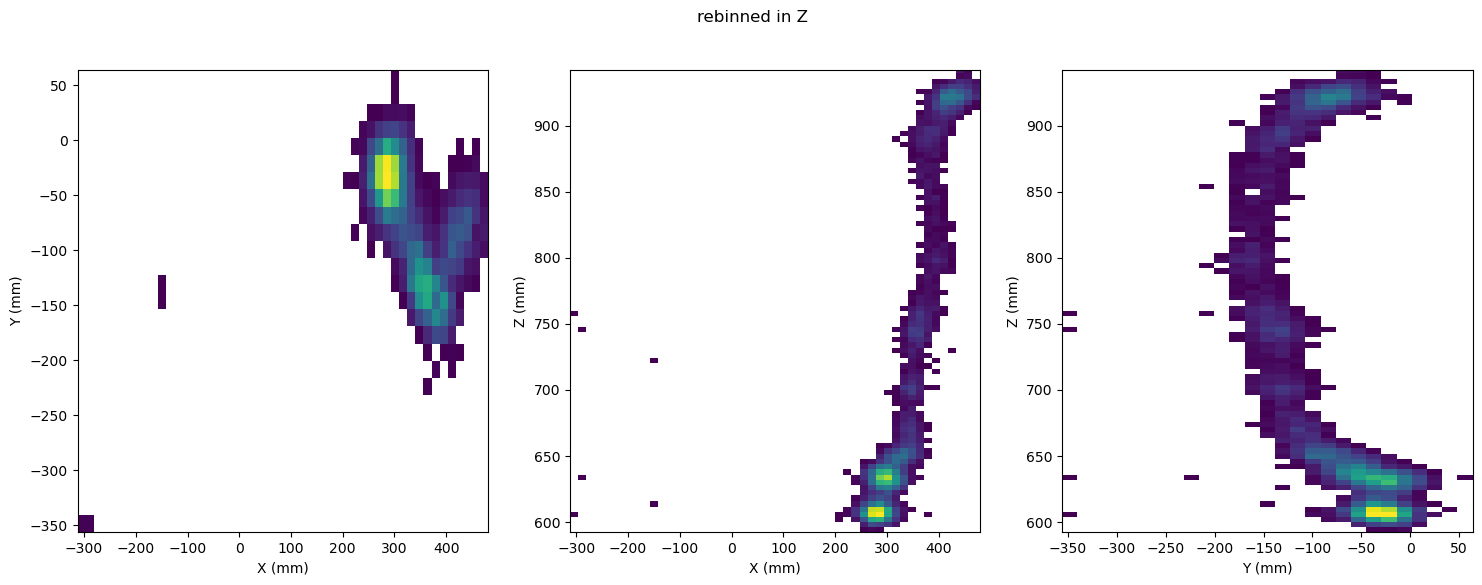

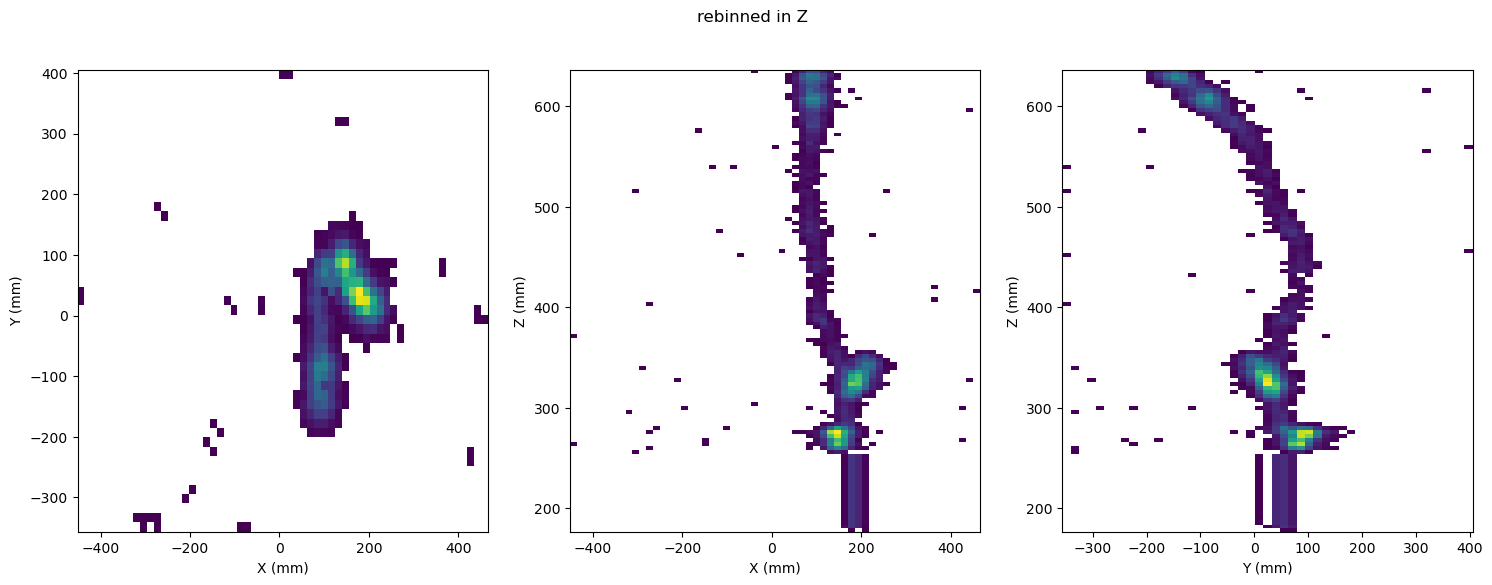

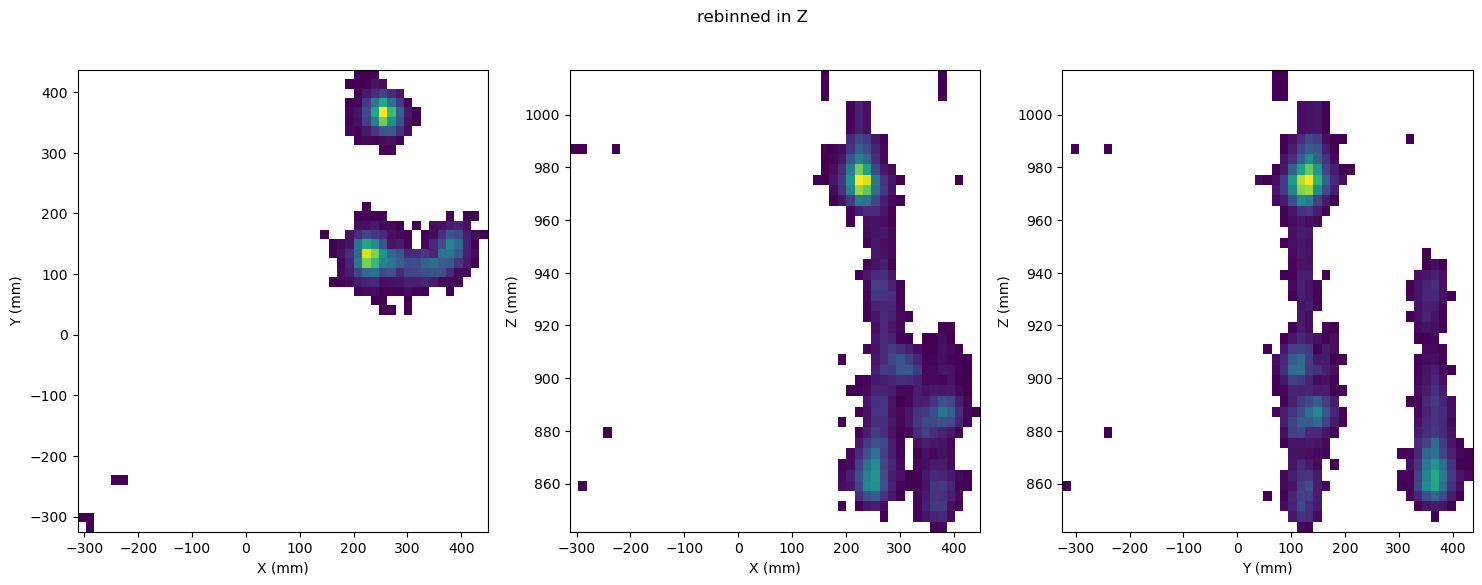

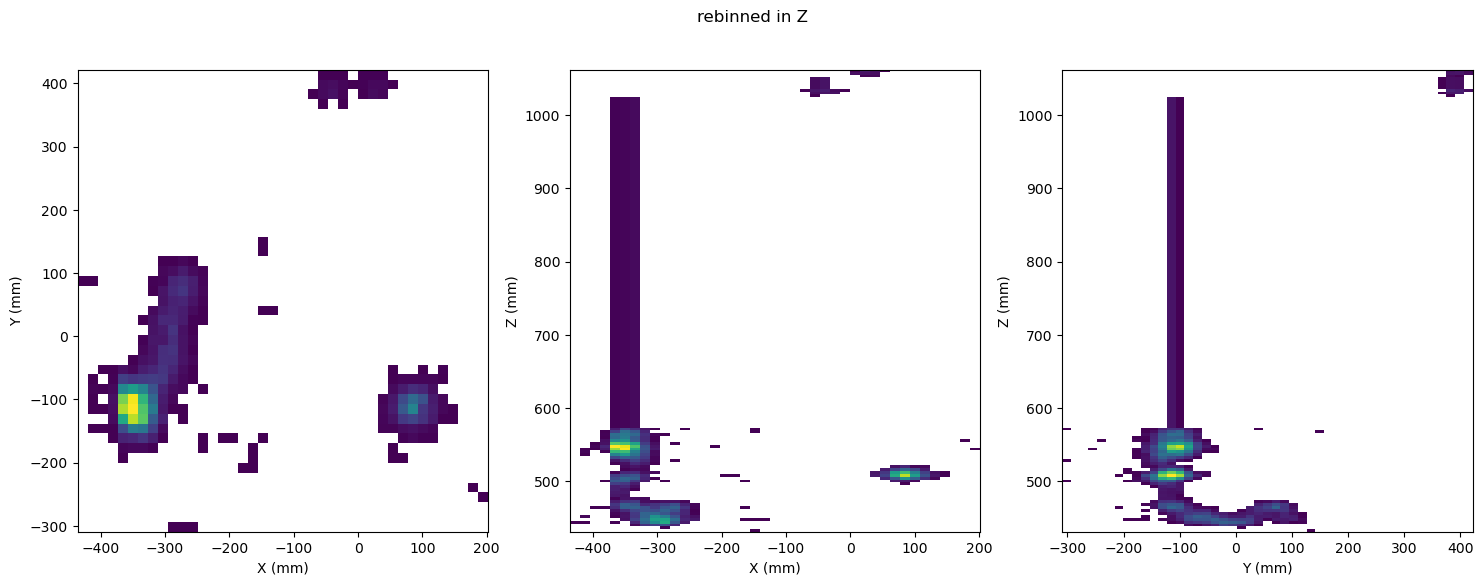

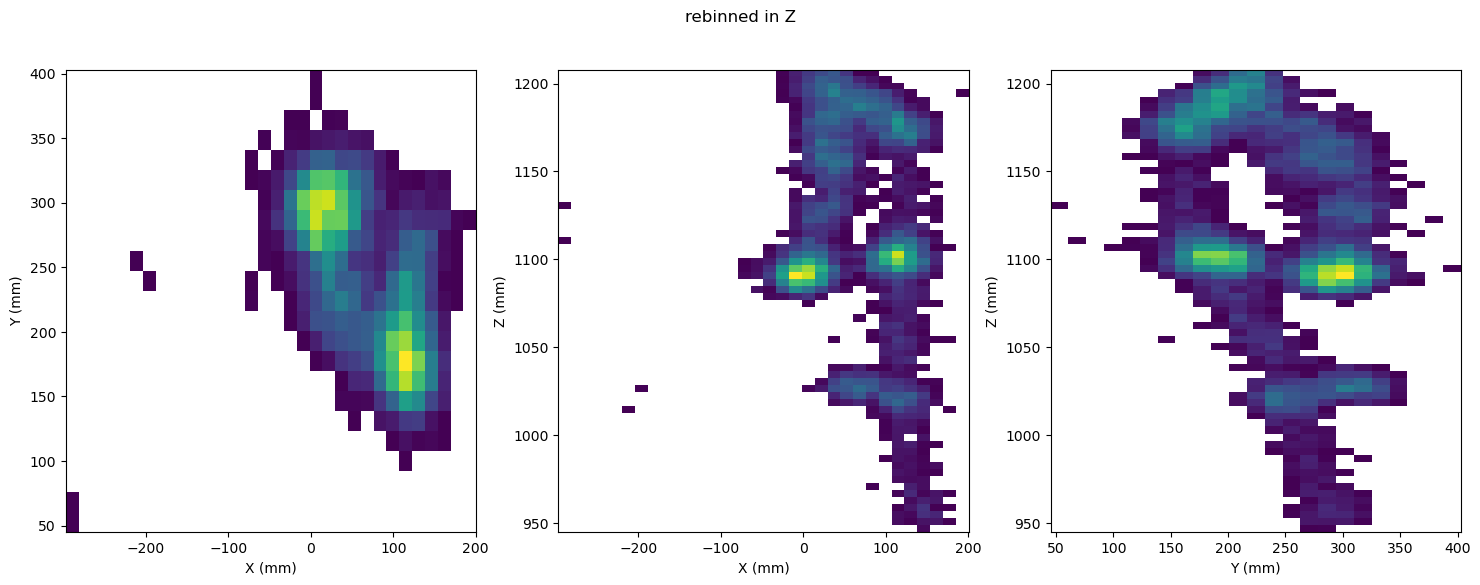

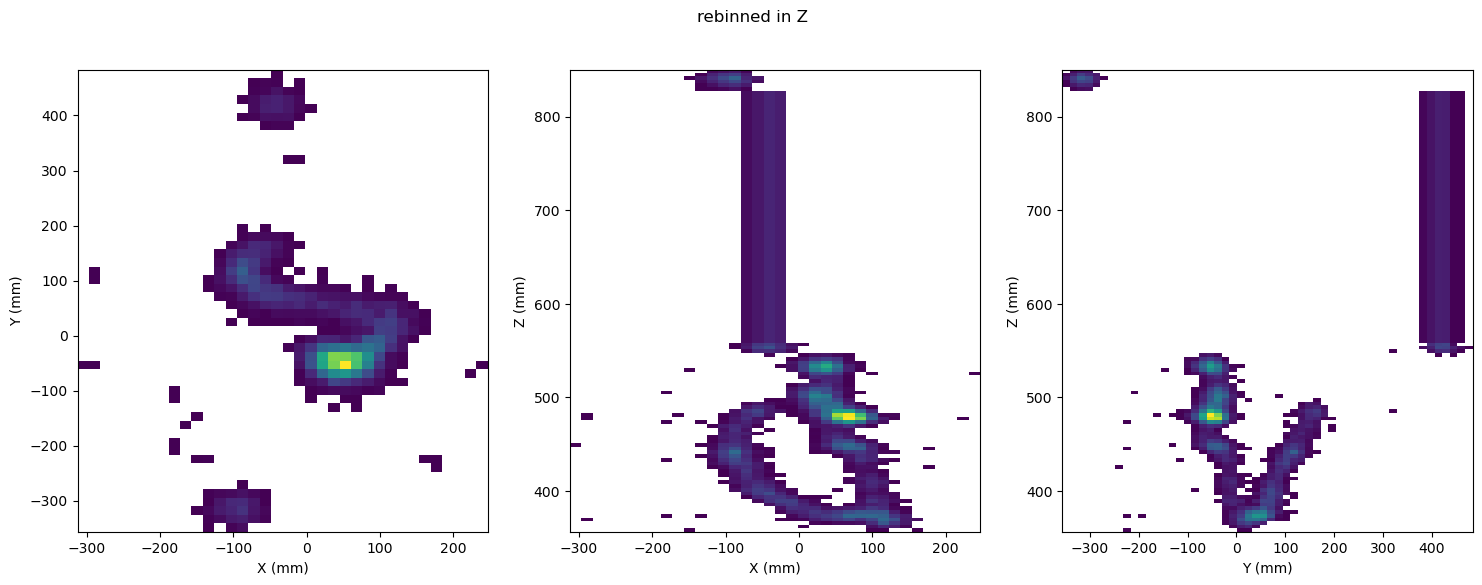

In [33]:
for evt, df in lsc_EOI_working[1].groupby('event'):
    raw_plotter(df, evt)

In [38]:
def plotter_3d(df, evt, cut_n_drop = True, show = True, clrbar = True, alpha = 0.65, min_s = 1, max_s = 15, cut_sensors = None, drop_sensors = None):
    '''
    evt_interest - df
    evt          - event number

    '''
    # plot
    evt_interest = df[df.event == evt]

    if cut_n_drop:
        hits_cut = coref.timefunc(cut_sensors)(evt_interest.copy())
        hits_drop = coref.timefunc(drop_sensors)(hits_cut.copy())
    else:
        hits_drop = evt_interest.copy(deep = True)
    
    xt = hits_drop.X
    yt = hits_drop.Y
    zt = hits_drop.Z
    et = hits_drop.E
    
    fig = plt.figure()
    #fig.suptitle('3D post deconvolution ' + str(evt), fontsize=30)
    fig.suptitle(f'Electron candidate event {evt}', fontsize=30)
    ax = fig.add_subplot(111, projection='3d')
    
    
    
    ets = et > 0 # eliminate small things for measurement
    
    max_val = max(et[ets])
    scaled_clipped = [max((v / max_val) * max_s, min_s) for v in et[ets]]

    #p = ax.scatter(x[em], y[em], z[em], c=e[em], alpha=0.3, cmap='viridis')
    #plt_sphere([(-track.blob2_x.values[0], -track.blob2_y.values[0], -track.blob2_z.values[0])], [blobR])
    p = ax.scatter([xt[ets]], yt[ets], zt[ets], c=et[ets], alpha=alpha, cmap='viridis', s = scaled_clipped)#, s = et[ets])
    #q = ax.scatter(xt, yt, zt, alpha = 0.3, color = 'red')
    
    # overlay the blobs and their radii
    if clrbar:
        cb = fig.colorbar(p, ax=ax)
        cb.set_label('Energy (keV)')
    
    
    ax.set_xlabel('\nx (mm)')
    ax.set_ylabel('\ny (mm)')
    ax.set_zlabel('\nz (mm)')
    
    #ax.set_xlim([-300, -100])
    #ax.set_ylim([250, 450])
    #ax.set_zlim([1600, 1800])
    #ax.view_init(20, -150)
    
    #plt.savefig(f'gif_making/deconv/angle_{i}.png')
    #plt.savefig(f'plots/hits_3d_{evt}.pdf')
    if show:
        plt.show()

    return hits_drop

In [5]:
min_s = 0
max_s = 100
alpha = 0.5
clrbar = True

# plot and compare each event
for lsc_evt, thr_evt in zip(lsc_EOI_working, thr_EOI_working):
    
    
    pitch = 15.55
    try:
        for ((lsc, df_lsc), (thr, df_thr)) in zip(lsc_evt.groupby('event'), thr_evt.groupby('event')):
            w, h = plt.figaspect(0.5)
            fig = plt.figure(figsize=(w * 2, h * 2))
            ax = fig.add_subplot(1, 2, 1, projection='3d')

            xt_lsc = df_lsc.X
            yt_lsc = df_lsc.Y
            zt_lsc = df_lsc.Z
            et_lsc = df_lsc.E

            xt_thr = df_thr.X
            yt_thr = df_thr.Y
            zt_thr = df_thr.Z
            et_thr = df_thr.E
            
            
            #fig.suptitle('3D post deconvolution ' + str(evt), fontsize=30)
            fig.suptitle(f'Electron candidate event {evt}', fontsize=30)
            

            ets_thr = et_thr > 0 # eliminate small things for measurement
            ets_lsc = et_lsc > 0 # eliminate small things for measurement

            max_val_thr = max(et_thr[ets_thr])
            scaled_clipped_thr = [max((v / max_val_thr) * max_s, min_s) for v in et_thr[ets_thr]]

            
            max_val_lsc = max(et_lsc[ets_lsc])
            scaled_clipped_lsc = [max((v / max_val_lsc) * max_s, min_s) for v in et_lsc[ets_lsc]]

            
            #p = ax.scatter(x[em], y[em], z[em], c=e[em], alpha=0.3, cmap='viridis')
            #plt_sphere([(-track.blob2_x.values[0], -track.blob2_y.values[0], -track.blob2_z.values[0])], [blobR])
            p0 = ax.scatter([xt_thr[ets_thr]], yt_thr[ets_thr], zt_thr[ets_thr], c=et_thr[ets_thr], alpha=alpha, cmap='viridis', s = scaled_clipped_thr)#, s = et[ets])
            ax.set_title('this_should_be_threshold')
            ax1 = fig.add_subplot(1,2,2, projection = '3d')
            p1 = ax1.scatter([xt_lsc[ets_lsc]], yt_lsc[ets_lsc], zt_lsc[ets_lsc], c=et_lsc[ets_lsc], alpha=alpha, cmap='viridis', s = scaled_clipped_lsc)#, s = et[ets])
            #q = ax.scatter(xt, yt, zt, alpha = 0.3, color = 'red')
            
            ax1.set_xlim(ax.get_xlim())
            ax1.set_ylim(ax.get_ylim())
            ax1.set_zlim(ax.get_zlim())
            # overlay the blobs and their radii
            if clrbar:
                cb = fig.colorbar(p1, ax=ax)
                cb.set_label('Energy (keV)')


            ax.set_xlabel('\nx (mm)')
            ax.set_ylabel('\ny (mm)')
            ax.set_zlabel('\nz (mm)')          
            
            event = df_lsc.event.unique()[0]
            plt.suptitle(f'evt{event} - LSC vs RAW')
            plt.savefig(f'comparisons_3D/{event}')
            plt.close()
    except Exception as e:
        print(f'broke: {e}')

NameError: name 'lsc_EOI_working' is not defined

In [3]:
low_thr_files = glob('low_thr/*000[0-9]*')
low_thr_files  = sorted(low_thr_files, key=lambda f: int(re.search(r'_000(\d)_', f).group(1)))

lsc_run_files = glob('lsc_run/*000[0-9]*')
lsc_run_files = sorted(lsc_run_files, key=lambda f: int(re.search(r'_000(\d)_', f).group(1)))

print(low_thr_files)
print(lsc_run_files)


['low_thr/run_15281_0000_ldc1.h5', 'low_thr/run_15281_0001_ldc1.h5', 'low_thr/run_15281_0002_ldc1.h5', 'low_thr/run_15281_0003_ldc1.h5', 'low_thr/run_15281_0004_ldc1.h5', 'low_thr/run_15281_0005_ldc1.h5', 'low_thr/run_15281_0006_ldc1.h5', 'low_thr/run_15281_0007_ldc1.h5', 'low_thr/run_15281_0008_ldc1.h5', 'low_thr/run_15281_0009_ldc1.h5']
['lsc_run/run_15281_0000_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0001_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0002_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0003_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0004_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0005_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0006_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0007_ldc1_trg2.v2.3.1.20250429.HEDesman.sophronia.h5', 'lsc_run/run_15281_0008_ldc1_trg2.v2.3.1.20250429.HEDesman.sophron

## Plot wrt hits < 2 sigma

In [35]:
# define cut_over_Q and drop_isolated object
q_thr     = 7
drop_dist = [15.55, 15.55]

cut_sensors   = cut_over_Q(q_thr, ['E', 'Ec'])
drop_sensors  = drop_isolated(drop_dist, ['E', 'Ec'])

# list of evts
evts = [177, 219, 737, 842, 849, 954, 1045, 1087, 1094]

# generate folders to store data
for evt in evts:
    Path(f'evt{evt}_images').mkdir(parents=True, exist_ok=True)

lsc_EOI = []
thr_EOI = []
for lsc_file, thr_file in tqdm(zip(lsc_run_files, low_thr_files)):

    df_lsc = load_dst(lsc_file, 'RECO', 'Events')
    df_thr = load_dst(thr_file, 'RECO', 'Events')
    # extract the events of interest from the df
    df_lsc = df_lsc[df_lsc.event.isin(evts)]
    df_thr = df_thr[df_thr.event.isin(evts)]
    # cut and drop
    #df_lsc  = cut_sensors(df_lsc)
    #df_thr  = cut_sensors(df_thr)
    
    #df_lsc  = drop_sensors(df_lsc)
    #df_thr  = drop_sensors(df_thr)

    lsc_EOI.append(df_lsc)
    thr_EOI.append(df_thr)


10it [05:12, 31.20s/it]


In [36]:
# concat
lsc_EOI = pd.concat(lsc_EOI[:2])
thr_EOI = pd.concat(thr_EOI[:2])


In [77]:
# kill the screamers
print(lsc_EOI.shape[0])
lsc_EOI = lsc_EOI[~((lsc_EOI.X == 243.225) & (lsc_EOI.Y == -340.975))]
print(lsc_EOI.shape[0])

print(thr_EOI.shape[0])
thr_EOI = thr_EOI[~((thr_EOI.X == 243.225) & (thr_EOI.Y == -340.975))]
print(thr_EOI.shape[0])


16814
16814
7544320
7542215


Initial hits:         2281
Mean & stdev:         18.551747357411532 & 14.575906003660295
SANITY CHECK, median: 13.651507377624512
Post 2*std cut:       112


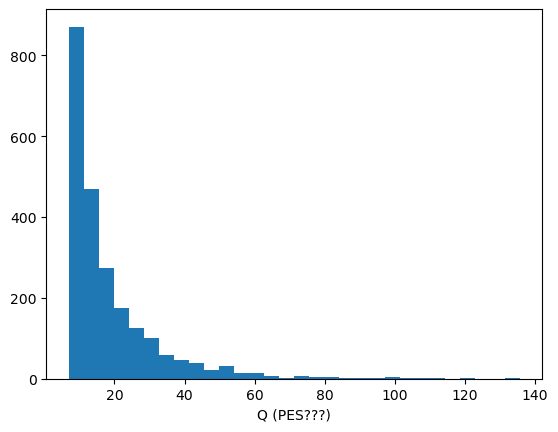

In [78]:
# poissonian sigma, so:

# noise in sipm per mus is ~ 0.07 PEs
# multiply by 4 to get per slice we have ~ 0.28 PEs
pes_per_slice = 0.28 # PEs


lsc_EOI_passing = []

# extract only the hits above 2 sigma
for i, df in lsc_EOI.groupby('event'):
    
    #take the mean q of the hits, then the standard deviation
    mean = df.Q.mean()
    std  = df.Q.std()
    
    # only keep hits above 2 sigma of mean
    df_pass = (df[df.Q > (mean + 2*std)])
    
    print('='*20)
    print(f'Initial hits:         {df.shape[0]}')
    print(f'Mean & stdev:         {mean} & {std}')
    print(f'SANITY CHECK, median: {df.Q.median()}')
    print(f'Post 2*std cut:       {df_pass.shape[0]}')
    print('='*20)
    plt.hist(df.Q.values, bins = 30)
    plt.xlabel('Q (PES???)')
    break




Number of unique z slices: 245
Noise value for number of unique z slices: 68.60000000000001
Initial hits:         877835
Post noise cut:       36
Before the cut:


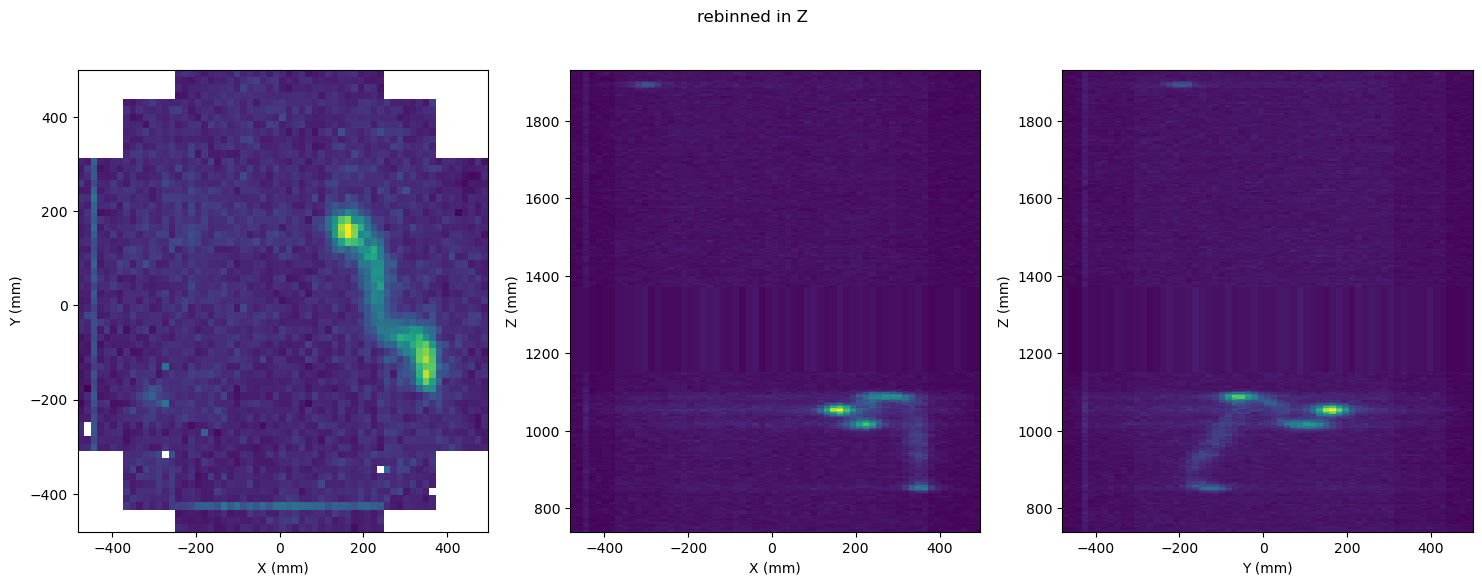

After the cut:


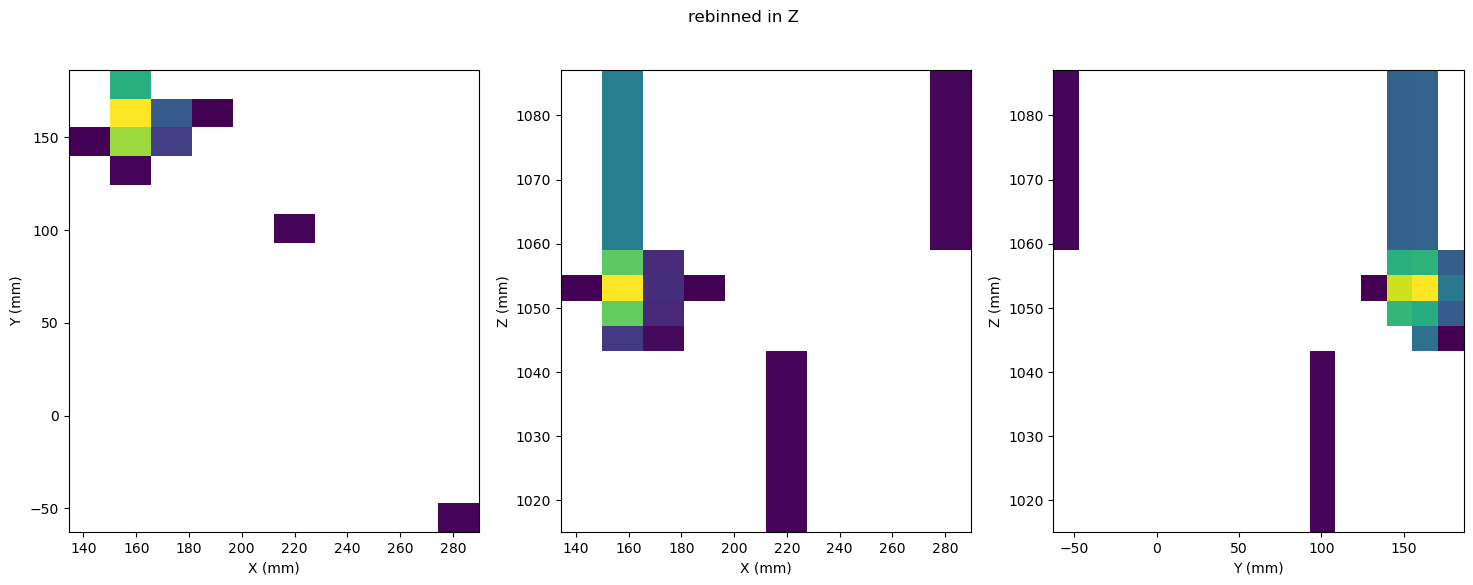

In [101]:
# poissonian sigma, so:

# noise in sipm per mus is ~ 0.07 PEs
# multiply by 4 to get per slice we have ~ 0.28 PEs
pes_per_slice = 0.28 # PEs


thr_EOI_passing = []


# extract only the hits above 2 sigma
for i, df in thr_EOI.groupby('event'):
    # take the number of unique Z components --> slices
    noise             = df.Z.nunique()*pes_per_slice
    
    print('='*20)
    print(f'Number of unique z slices: {df.Z.nunique()}')
    print(f'Noise value for number of unique z slices: {noise}')
    #print(f'Uncertainty on this noise value: {}')
    # only keep hits above 2 sigma of mean
    df_pass = (df[df.Q > (noise)])
    
    
    print(f'Initial hits:         {df.shape[0]}')
    print(f'Post noise cut:       {df_pass.shape[0]}')
    print('='*20)
    #plt.hist(df.Q.values, bins = 30, range = [0, 7.5])
    #plt.xlabel('Q (PES???)')
    #plt.show()
    
    #plt.hist(df.Q.values, bins = 30, range = [7, 100])
    #plt.xlabel('Q (PES???)')
    #plt.show()
    print('Before the cut:')
    raw_plotter(df, i)
    print('After the cut:')
    raw_plotter(df_pass, i)
    
    break




Initial hits:         2281
Mean & stdev:         18.551747357411532 & 14.575906003660295
SANITY CHECK, median: 13.651507377624512
Post 2*std cut:       2110


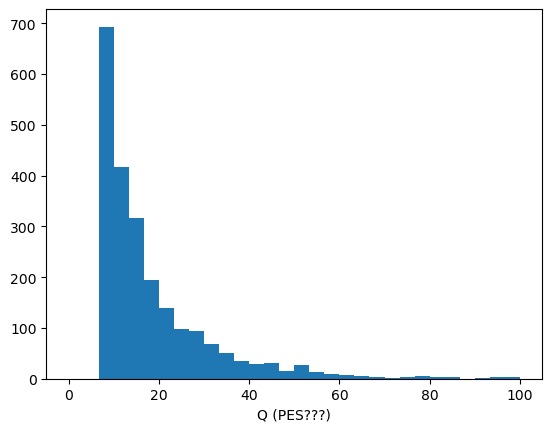

Before the cut:


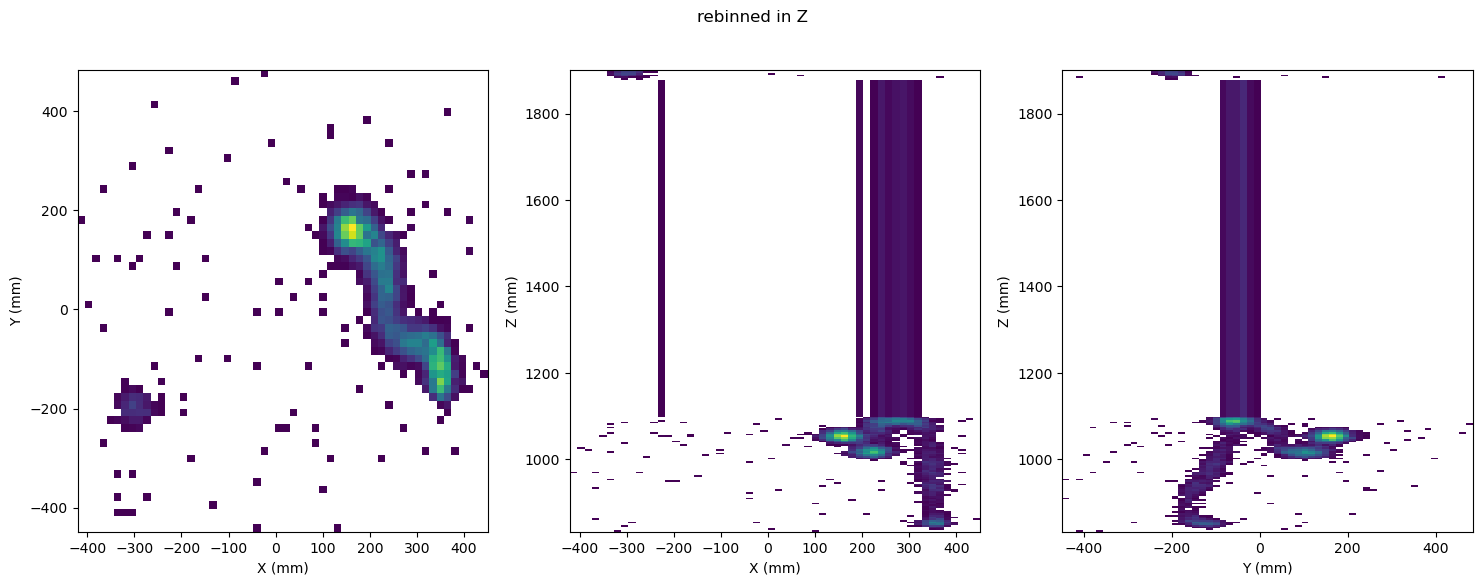

After the cut:


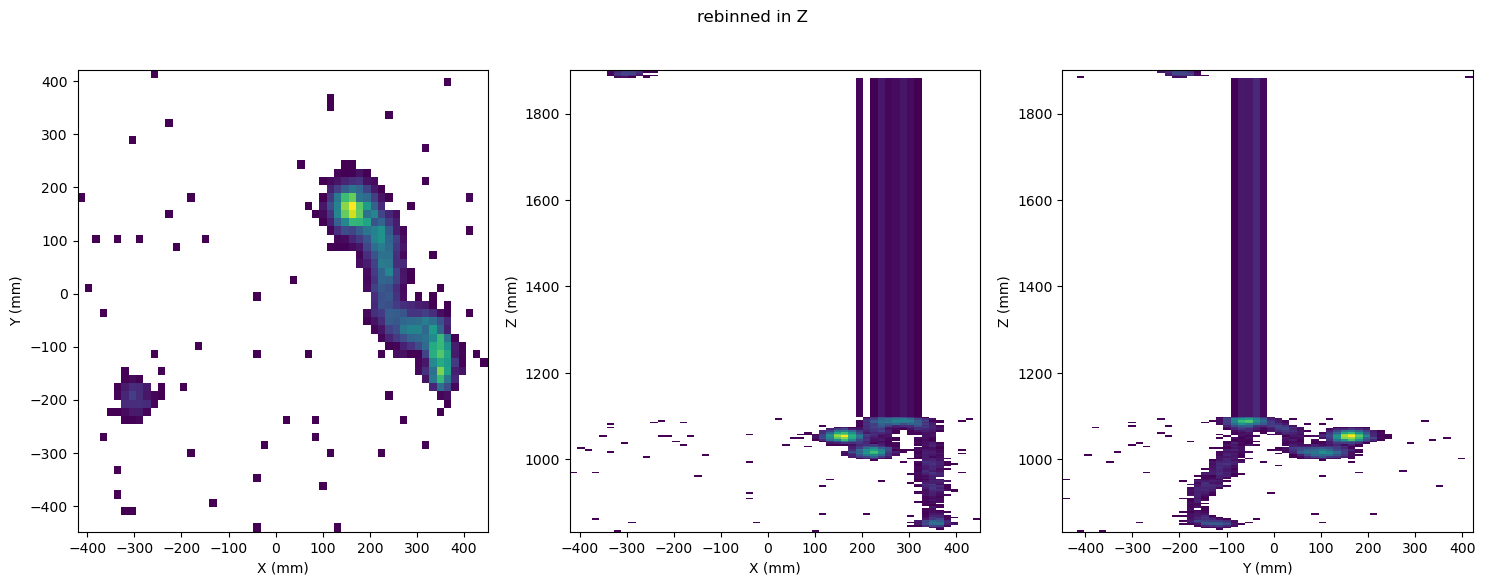

In [91]:



lsc_EOI_passing = []

# extract only the hits above 2 sigma
for i, df in lsc_EOI.groupby('event'):
    #take the mean q of the hits, then the standard deviation
    mean = df.Q.mean()
    std  = df.Q.std()
    
    # only keep hits above 2 sigma of mean
    df_pass = (df[df.Q > 7.523623658965917])
    
    print('='*20)
    print(f'Initial hits:         {df.shape[0]}')
    print(f'Mean & stdev:         {mean} & {std}')
    print(f'SANITY CHECK, median: {df.Q.median()}')
    print(f'Post 2*std cut:       {df_pass.shape[0]}')
    print('='*20)
    plt.hist(df.Q.values, bins = 30, range = [0, 100])
    plt.xlabel('Q (PES???)')
    plt.show()
    print('Before the cut:')
    raw_plotter(df, i)
    print('After the cut:')
    raw_plotter(df_pass, i)
    
    break



Initial hits        :         877835
Median & scaled MAD :         0.2387746125459671 & 0.2690162429071963
Post 2*std cut      :       276125
Before the cut:


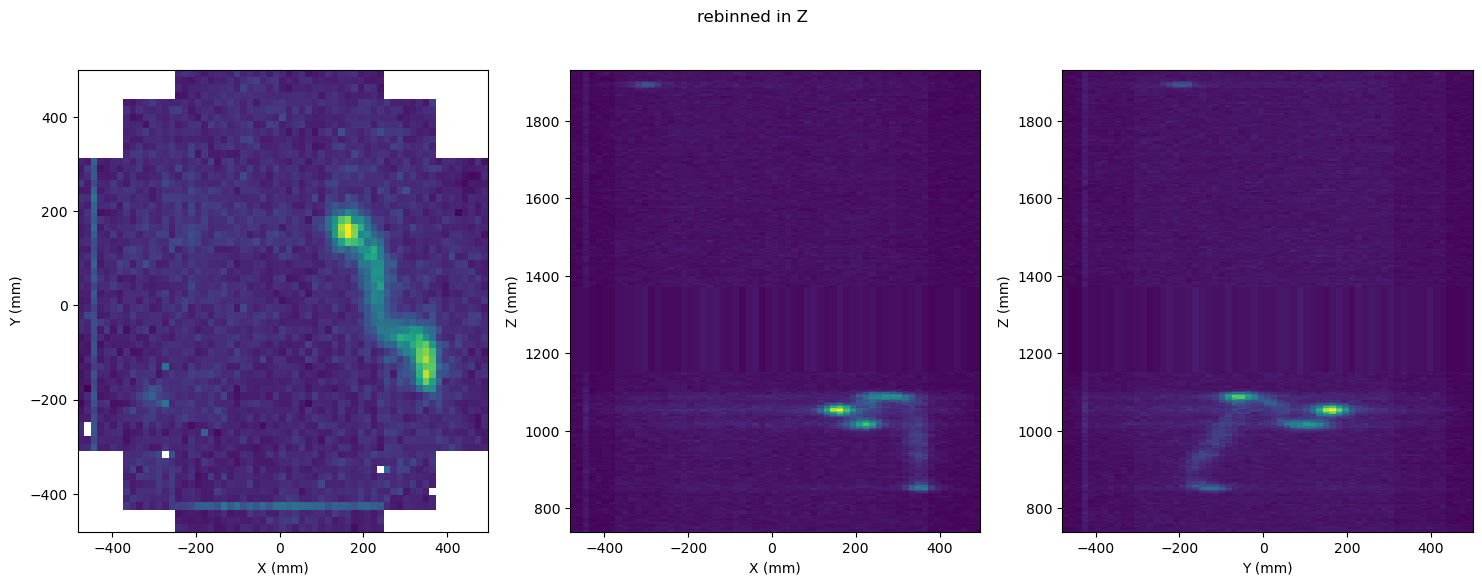

After the cut:


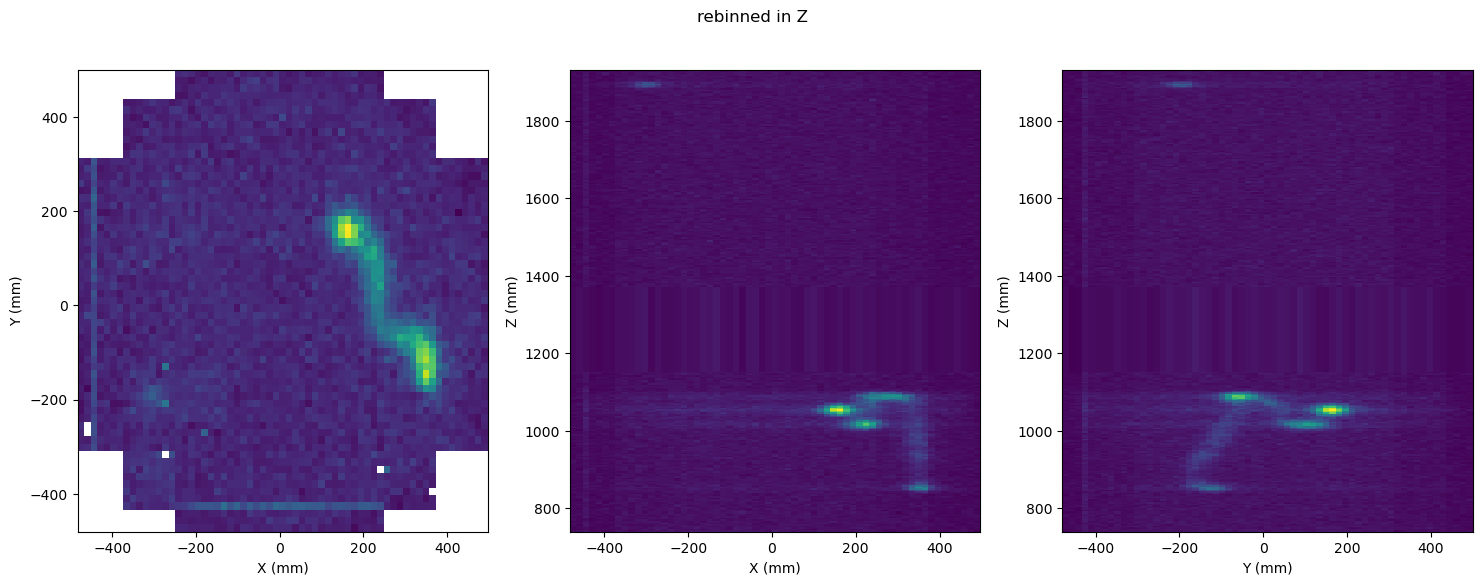

In [80]:

thr_EOI_passing = []

# extract only the hits above 2 sigma
for i, df in thr_EOI.groupby('event'):
    #take the mean q of the hits, then the standard deviation
    median = df.Q.median()
    mad = np.median(np.abs(df["Q"] - median))

    # 1.4826 rescales MAD to be comparable to std for a normal distribution
    robust_sigma = 1.4826 * mad

    df_pass = df[df["Q"] > median + 2 * robust_sigma]
    
    print('='*20)
    print(f'Initial hits        :         {df.shape[0]}')
    print(f'Median & scaled MAD :         {median} & {robust_sigma}')
    
    print(f'Post 2*std cut      :       {df_pass.shape[0]}')
    print('='*20)
    print('Before the cut:')
    raw_plotter(df, i)
    print('After the cut:')
    raw_plotter(df_pass, i)
    
    break

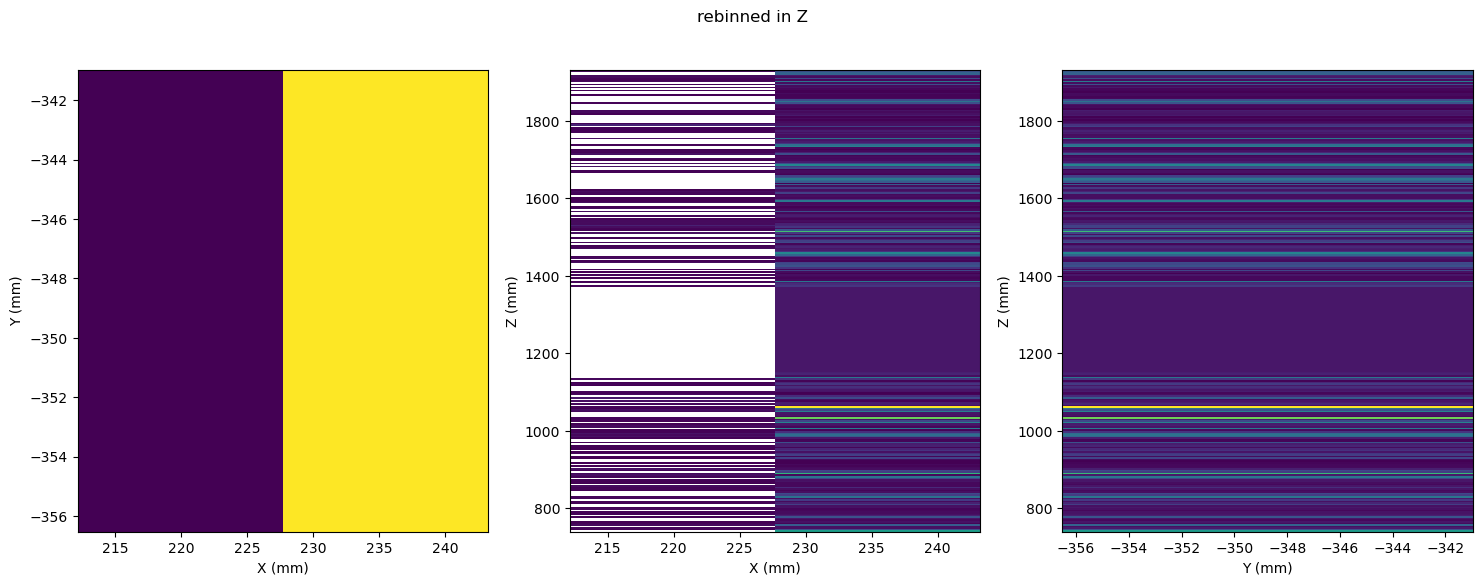

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
7797624,177,1.746555e+09,22,51.369641,10.489568,1,243.225,-356.525,0.0,0.0,739.245375,2.301287,-0.008337,-1.0,-1.0,-1,-1.0
7797625,177,1.746555e+09,22,51.369641,10.489568,1,243.225,-340.975,0.0,0.0,739.245375,42.142090,-0.152662,-1.0,-1.0,-1,-1.0
7801193,177,1.746555e+09,22,51.369641,10.489568,1,212.125,-340.975,0.0,0.0,743.191375,1.352789,-0.007063,-1.0,-1.0,-1,-1.0
7801209,177,1.746555e+09,22,51.369641,10.489568,1,243.225,-340.975,0.0,0.0,743.191375,19.878344,-0.103790,-1.0,-1.0,-1,-1.0
7804776,177,1.746555e+09,22,51.369641,10.489568,1,212.125,-356.525,0.0,0.0,747.154375,2.308585,-0.007231,-1.0,-1.0,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8668529,177,1.746555e+09,26,2.257494,8.962107,1,227.675,-340.975,0.0,0.0,1928.790500,1.378938,0.001589,-1.0,-1.0,-1,-1.0
8668536,177,1.746555e+09,26,2.257494,8.962107,1,243.225,-356.525,0.0,0.0,1928.790500,2.664648,0.003071,-1.0,-1.0,-1,-1.0
8668537,177,1.746555e+09,26,2.257494,8.962107,1,243.225,-340.975,0.0,0.0,1928.790500,19.083210,0.021994,-1.0,-1.0,-1,-1.0
8672112,177,1.746555e+09,26,2.257494,8.962107,1,227.675,-356.525,0.0,0.0,1932.095000,1.856799,-0.003569,-1.0,-1.0,-1,-1.0


[243.225 212.125 227.675]
[-356.525 -340.975]


In [66]:
condition = (df_pass.X > 200) & (df_pass.X < 250) & (df_pass.Y > -360) & (df_pass.Y < -330)
raw_plotter(df_pass[condition], 177)
display(df_pass[condition])

print(df_pass[condition].X.unique())
print(df_pass[condition].Y.unique())

In [75]:
display((df_pass[(df_pass.X == 243.225) & (df_pass.Y == -340.975)].Q.values))


array([42.14208984, 19.87834358,  2.38540125,  3.97566891, 21.46861267,
        1.59026754,  0.79513377,  1.59026754,  2.38540125, 20.67347717,
        6.36107016,  3.18053508,  3.18053508,  0.79513377,  0.79513377,
        3.18053508,  3.97566891, 15.10754204,  4.7708025 ,  1.59026754,
       12.72214031,  3.97566891, 30.21508408, 15.10754204, 17.49294281,
        2.38540125,  1.59026754,  0.79513377,  1.59026754,  2.38540125,
        2.38540125,  0.79513377,  3.97566891,  3.18053508, 15.90267563,
       29.41995049,  2.38540125, 52.47882843, 15.10754204, 15.10754204,
        2.38540125,  1.59026754,  1.59026754,  2.38540125,  0.79513377,
        0.79513377,  1.59026754, 15.90267563,  0.79513377, 15.10754204,
        8.74647141,  1.59026754, 11.13187313,  6.36106968,  3.97566891,
        4.7708025 , 19.87834358,  0.79513377,  0.79513377,  2.38540125,
       18.2880764 , 26.23941422, 23.85401535, 10.33673859,  0.79513377,
       32.60048676,  0.79513377,  3.18053508,  2.38540125, 33.39

In [53]:
df_pass.Y.unique()

array([-248.175, -217.075, -279.275, -201.525, -294.825, -263.725,
       -232.625, -185.975, -155.875, -124.775,  -78.125, -140.325,
       -171.425,  -93.675, -109.225,  -32.475,   14.175,   29.725,
        -48.025,  -16.925,   45.275,   -1.375,   60.825,   75.375,
        137.575,  168.675,   90.925,  106.475,  184.225,  122.025,
        153.125,  260.975,  214.325,  229.875,  292.075,  307.625,
        198.775,  276.525, -387.125, -402.675, -324.925, -371.575,
       -356.025, -309.375, -418.225, -340.475,  -62.575,  245.425,
        337.725,  353.275,  368.825,  399.925,  322.175,  415.475,
        384.375,  431.025, -402.175, -386.625, -417.725, -371.075,
       -433.275, -479.925, -464.375, -448.825, -356.525, -309.875,
       -278.775, -263.225, -247.675, -294.325, -340.975, -202.025,
       -170.925, -155.375, -186.475, -217.575, -233.125, -139.825,
       -124.275, -109.725,  -78.625,  -63.075,  -16.425,   -0.875,
        -31.975,  -94.175,  -47.525,   75.875,   13.675,   29.